# Behavioral Segmentation and Completion Outcome Analysis

---

## Project Overview

### Objective

This project represents **Part 2** of the analytical workflow for the Interactive **Data Analysis in R Course** on **Stepik Platform**.

The main objective of this phase is to segment users based on their resolved learning behavior and examine how these behavioral profiles are associated with course completion outcomes.

[**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb) identified the main product problem as an early **Activation Gap**: many users disengage before moving from passive content consumption into meaningful practical engagement. Building on this diagnostic finding, **Part 2** uses unsupervised learning to summarize heterogeneous learner behavior into interpretable, business-actionable segments.

The goal of this phase is not to predict completion directly. Instead, the segmentation is used to understand which broad behavioral patterns exist among learners and how these patterns relate to completion outcomes.

The resulting segments provide an interpretive bridge between the descriptive product diagnosis in [**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb)  and the supervised completion-risk modeling in [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb).

---

### Project Context

This analytical workflow is organized into three connected stages.

[**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb) 

The first phase analyzed raw Stepik event and submission logs to identify where learners disengage during the course journey. It showed that the largest observed loss occurs before the first meaningful practical action, particularly before learners start or submit practical assignments. This early behavioral bottleneck was summarized as the **Activation Gap**.

The first phase also prepared the analytical foundation for all downstream analyses by applying P99-based filtering, excluding learners whose trajectories were still considered **in progress** using a **14-day inactivity threshold**, constructing user-level behavioral features, and exporting the processed datasets for segmentation and prediction.

**Part 2: Behavioral Segmentation and Completion Outcome Analysis**  

This phase uses the resolved `model_base` sample to identify behaviorally distinct learner groups with K-means clustering. The resulting clusters are validated, profiled, interpreted, and then compared by completion outcome.

[**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) 

The final phase uses early **10-day** behavioral and progress-aware features. to estimate each learner's probability of eventual course completion and to rank learners by non-completion risk.

Cluster labels obtained in Part 2 are treated as an exploratory business segmentation tool and are **not** used as supervised model features in Part 3. This keeps the prediction pipeline based on observable early-window behavioral and progress-related features rather than post-hoc cluster assignments.

---

### Data Description

The analysis is based on processed user-level datasets derived from the `model_base` sample prepared in [**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb) .

The `model_base` sample excludes:

- P99-defined extreme high-activity users,
- users still marked as unresolved `is_in_progress` at the dataset snapshot.

This makes the segmentation focus on resolved learner trajectories and reduces the influence of extreme or incomplete behavioral records.

**1. `cluster_features_model_base.csv`**

This dataset contains user-level behavioral features used for clustering.

**Granularity**

- **1 row = 1 user**
- **Total users:** 18,168 

Main feature groups include:

**Engagement continuity**

- `active_days`
- `median_gap_days`

**Interaction intensity**

- `view_frequency`
- `submission_frequency`

**Learning pace and productivity**

- `steps_per_active_day`
- `score_per_active_day`

**Practical success behavior**

- `submission_correct_rate`

**2. `completion_target_model_base.csv`**

This dataset contains the final binary completion label for each user:

- `Completed`
- `Not_Completed`

The final completion label is used only after clustering for segment interpretation and is not included directly in the clustering feature space. However, the clustering features include performance-related variables, particularly `score_per_active_day`, which is derived from the accumulated score also used to define course completion. Therefore, completion differences across segments are interpreted descriptively rather than as an independent validation of the clustering solution.

---

### Analytical Framing

This phase treats user behavior as heterogeneous rather than assuming that all non-completers disengage in the same way.

The segmentation is designed to answer the following business question:

**What types of learner behavior exist in the resolved user population, and how are these patterns associated with completion outcomes?**

The clustering does not use the final completion label directly. However, the feature space includes both behavioral and performance-related variables, including score_per_active_day, which is derived from the accumulated score used to define completion.

The resulting segments are therefore interpreted as mixed behavioral-performance archetypes rather than supervised prediction classes. Differences in completion rates are analyzed descriptively and should not be treated as fully independent validation of the cluster structure.

---

### Methodological Strategy

The workflow follows a structured unsupervised learning process.

1. **Data loading and integrity checks**
   - Load the processed clustering feature dataset and completion target dataset.
   - Verify user-level uniqueness.
   - Confirm that both datasets contain the same `user_id` set.
   - Check for missing values, invalid values, infinite values, duplicate users, and zero-variance features.

2. **Exploratory analysis of clustering features**
   - Inspect distributions of behavioral variables.
   - Identify right-skewness and residual local extreme values within the resolved sample.
   - Review the completion outcome distribution for later post-clustering interpretation.

3. **Feature preprocessing**
   - Apply `log1p` transformation to heavily right-skewed behavioral activity features.
   - Preserve `median_gap_days` in its original scale to retain behavioral meaning.
   - Apply Z-score normalization before K-means clustering.
   - Review the correlation structure to check for strong redundancy.

4. **K-means model selection**
   - Compare candidate cluster solutions.
   - Review the Elbow Method and Silhouette Score.
   - Compare $K = 3$, $K = 4$, and $K = 5$ directly.
   - Evaluate whether higher-K solutions improve analytical value or mainly create small fragmented groups.

5. **Cluster validation**
   - Review cluster size distribution.
   - Use bootstrap-based stability diagnostics.
   - Compare K-means results with PAM as an additional robustness check.
   - Assess business interpretability of candidate solutions.

6. **Final cluster assignment and profiling**
   - Assign users to the selected cluster solution.
   - Reorder cluster labels by segment size for clearer reporting.
   - Profile clusters using original-scale behavioral metrics.
   - Interpret each segment as a business-actionable learner archetype.

7. **Completion outcome analysis**
   - Merge cluster assignments with completion labels.
   - Compare completion outcomes across segments.
   - Interpret associations between behavioral profiles and completion status.

8. **Strategic interpretation and downstream connection**
   - Summarize how behavioral segmentation supports retention strategy.
  

---

### Cluster Selection

The number of clusters was selected using both statistical diagnostics and business interpretability.

The candidate solutions included $K = 3$, $K = 4$, and $K = 5$.

Although the $K = 4$ and $K = 5$ solutions showed slightly higher Silhouette Scores, the improvement was marginal. At the same time, both higher-K alternatives introduced a very small additional segment of approximately **1.0%** of users.

From a business perspective, such small segments were not treated as standalone operational groups because they would require separate interpretation and potentially separate intervention logic without sufficient evidence of additional business value.

Therefore, the final primary segmentation uses $K = 3$, because it provides larger, more interpretable, and more business-actionable learner groups.

---

### Resulting Segments

The final $K = 3$ solution identifies three learner segments.

**Passive Users (~49.9%)**  
Users with minimal engagement, almost no practical activity, and no observable score progress in the median profile.

**Steady Learners (~27.3%)**  
Users with sustained participation, moderate practical activity, and relatively stable learning progress.

**Burst Learners (~22.8%)**  
Users with concentrated high-intensity activity, strong practical engagement, and higher per-day productivity.

These segments capture meaningful differences in participation continuity, interaction intensity, practical engagement, and learning productivity.

---

### Completion Outcome Interpretation

The final completion label is merged only after cluster construction and is not used directly as a clustering variable. However, the clusters are partly shaped by performance-related features, including `score_per_active_day`, which is derived from accumulated course score.

The segment-level outcome distribution shows that `Not_Completed` remains the dominant outcome across all three segments. Completion is relatively more frequent among **Steady Learners** and **Burst Learners**, while **Passive Users** show almost no successful completion.

These differences are consistent with the broader Activation Gap identified in Part 1. However, because the clustering feature space already includes practical-progress and score-productivity signals, the completion comparison should be interpreted as a descriptive characterization of the segments rather than as independent evidence that the behavioral patterns alone explain completion.

---

### Key Analytical Questions

This project addresses five main questions:

1. **Can resolved learners be grouped into interpretable behavioral segments?**

2. **Which behavioral dimensions best distinguish learner profiles: continuity, intensity, productivity, or practical success?**

3. **Does a larger number of clusters improve business interpretability, or does it over-fragment the user base?**

4. **How are the final learner segments associated with completion outcomes?**

5. **How can behavioral segmentation inform downstream completion-risk modeling and retention strategy?**

---

### Key Findings

The analysis identifies several core findings.

**User engagement is highly heterogeneous.**  
The resolved learner population is not behaviorally uniform. Users differ substantially in continuity, activity intensity, practical engagement, and productivity.

**Most users belong to a low-engagement segment.**  
The largest segment is **Passive Users**, representing about half of the analytical sample. This group shows minimal engagement and almost no practical progress in the median profile.

**The final $K = 3$ solution is stable and business-actionable.**  
The selected segmentation produces three substantial user groups, avoids over-fragmentation, and is supported by bootstrap stability diagnostics and PAM comparison.

**The mixed behavioral-performance segments differ in completion share.**
Completion remains rare overall, but **Steady Learners** and **Burst Learners** show visibly higher completion shares than **Passive Users**. Because the clustering feature space includes score-productivity and practical-performance signals, these differences are interpreted descriptively.

**The segment profiles are consistent with the Activation Gap interpretation.**
The **Passive User** segment combines very low practical engagement, limited activity, weak performance signals, and an almost absent completion share. This pattern is consistent with the Activation Gap identified in [**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb), but it should not be treated as an independent causal validation.

**Cluster labels are useful for interpretation, not prediction inputs.**  
The segments summarize behavioral archetypes and support business reasoning, but they are not used directly as features in the supervised modeling workflow in [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb).

---

### Expected Business Use

The segmentation provides an exploratory business framework for understanding learner behavior. Because the segments are constructed from full-history resolved trajectories, they support retrospective profiling and population-level retention strategy design. The current clustering model is not intended for real-time assignment of new learners to intervention groups.

The three segments can support differentiated retention thinking:

**Passive Users** may require stronger onboarding, first-task prompts, simplified entry points, and activation support.

**Steady Learners** may benefit from progress feedback, consistency reinforcement, and completion-oriented nudges.

**Burst Learners** may benefit from momentum-based recommendations, achievement prompts, and advanced progression support.

The segment profiles differ in engagement continuity, practical activation, activity intensity, performance-related productivity, and observed completion share. Because performance-related variables are included in the clustering feature space, the completion differences should be interpreted descriptively rather than as independent predictive evidence.

[**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) moves from retrospective segmentation to supervised modeling. It estimates $P(Completed)$ from early 10-day behavioral and progress-aware features and converts it into a non-completion risk-ranking score:

`Risk_Not_Completed = 1 - P(Completed)`

---

### Assumptions & Limitations

**Assumptions**

- The processed datasets correctly represent the resolved analytical sample `model_base`.
- The selected clustering features capture meaningful dimensions of learner engagement, continuity, practical activity, and performance.
- Log transformation and Z-score normalization improve comparability across behavioral features for distance-based clustering.
- K-means provides a useful approximation of mixed behavioral-performance learner profiles, even though real user behavior may vary along a continuum rather than in perfectly separated groups.
- The final $K = 3$ solution is treated as the primary business segmentation because it provides substantial and interpretable user groups.

**Limitations**

- The analysis is restricted to `model_base`, which excludes both P99-defined extreme users and users still marked as `is_in_progress` at the dataset snapshot. Therefore, results should not be interpreted as a full-population view of all learners.
- Completion remains a rare outcome in the analytical sample, so segment-level completion comparisons should be interpreted descriptively rather than as causal or inferential evidence.
- K-means assumes relatively compact cluster structure and is sensitive to feature selection, scaling, and preprocessing choices.
- The 3-cluster solution prioritizes business interpretability and segment size over finer-grained separation. Rare small-segment patterns observed in the $K = 4$ and $K = 5$ candidate solutions are not treated as standalone operational segments.
- Some clustering features include performance-related signals such as `submission_correct_rate` and `score_per_active_day`. In particular, `score_per_active_day` is derived from the accumulated score also used to define the completion target. The segmentation should therefore be interpreted as a mixed behavioral-performance profile rather than a purely engagement-only segmentation, and differences in completion share should not be treated as independent validation of the clusters.
- The analysis is based on a historical snapshot and does not capture unobserved external factors that may influence learner outcomes.
- Cluster labels are not causal explanations and should not be interpreted as fixed learner types.

---

In [1]:
# Environment Setup
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(tidyr)
  library(corrplot)
  library(ggplot2)
  library(cluster)
  library(fpc)
  library(mclust)
})

---

## Data Loading 

In [2]:
# Project paths
project_root <- here::here()

data_dir <- file.path(project_root, "data")
processed_data_dir <- file.path(data_dir, "processed")

if (!dir.exists(processed_data_dir)) {
  stop(
    "Processed data directory does not exist: ",
    processed_data_dir
  )
}

In [3]:
# Using data.table::fread for high-performance data loading
cluster_features_model_base <- fread(file.path(processed_data_dir, "cluster_features_model_base.csv"))
completion_target_model_base <- fread(file.path(processed_data_dir, "completion_target_model_base.csv"))

In [4]:
# Display memory usage for the processed clustering and target datasets
cat("cluster_features_model_base size:", format(object.size(cluster_features_model_base), units = "MB"), "\n")
cat("completion_target_model_base size:", format(object.size(completion_target_model_base), units = "MB"), "\n")

cluster_features_model_base size: 1 Mb 
completion_target_model_base size: 0.2 Mb 


In [5]:
# Quick consistency check: verify dataset dimensions and user-level granularity
# Both datasets should contain 18,168 rows (one row per unique user)
# Column counts differ by design:
# - cluster_features_model_base: 8 columns
#   (`user_id` plus 7 clustering features)
# - completion_target_model_base: 2 columns 
dim(cluster_features_model_base)
dim(completion_target_model_base)

[1] 18168     8

[1] 18168     2

In [6]:
# Verification: Every row must represent one unique user (Primary Key check) - cluster_features_model_base
stopifnot(nrow(cluster_features_model_base) == n_distinct(cluster_features_model_base$user_id))

In [7]:
# Verification: Every row must represent one unique user (Primary Key check) - completion_target_model_base
stopifnot(nrow(completion_target_model_base) == n_distinct(completion_target_model_base$user_id))

In [8]:
# Verification: both datasets must contain the same user_id set
stopifnot(setequal(
  cluster_features_model_base$user_id,
  completion_target_model_base$user_id
))

---

## Exploratory Analysis

### EDA: Cluster Features

In [9]:
# Set seed for reproducibility of any sampling or randomized algorithms
set.seed(42)
cluster_features_model_base %>% slice_sample(n = 10)

user_id,active_days,median_gap_days,submission_correct_rate,view_frequency,submission_frequency,steps_per_active_day,score_per_active_day
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13684,1,0.0,0.0000000,7.0000000,0.00000000,4.000000,0.0000000
1828,1,0.0,0.6666667,25.0000000,3.00000000,10.000000,1.0000000
22895,11,1.0,0.4597701,9.7500000,5.43750000,9.454545,3.8181818
13004,16,2.0,0.7102804,4.7000000,1.78333333,12.375000,5.5000000
15137,1,0.0,0.0000000,1.0000000,0.00000000,1.000000,0.0000000
19786,3,1.0,0.1279621,92.3333333,70.33333333,20.333333,9.3333333
21164,23,2.5,0.6842105,1.1125402,0.18327974,4.869565,1.7826087
24699,18,1.0,0.3295455,7.8823529,1.72549020,4.166667,1.6111111
11342,6,19.0,0.6666667,0.2341137,0.01003344,2.000000,0.1666667


In [10]:
# Inspect dataset structure and variable types
glimpse(cluster_features_model_base)

Rows: 18,168
Columns: 8
$ user_id                 <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 2…
$ active_days             <int> 1, 2, 7, 2, 1, 2, 1, 1, 21, 1, 1, 1, 32, 1, 2,…
$ median_gap_days         <dbl> 0, 56, 2, 390, 0, 10, 0, 0, 2, 0, 0, 0, 1, 0, …
$ submission_correct_rate <dbl> 0.0000000, 1.0000000, 0.5576923, 0.5000000, 0.…
$ view_frequency          <dbl> 1.00000000, 0.17543860, 1.61344538, 0.03069054…
$ submission_frequency    <dbl> 0.00000000, 0.03508772, 0.43697479, 0.01023018…
$ steps_per_active_day    <dbl> 0.000000, 4.500000, 12.428571, 5.500000, 1.000…
$ score_per_active_day    <dbl> 0.0000000, 0.5000000, 4.1428571, 0.5000000, 0.…


In [11]:
# Review summary statistics to validate ranges and overall consistency
options(scipen = 999)
summary(cluster_features_model_base[, !c("user_id"), with = FALSE])

  active_days      median_gap_days    submission_correct_rate view_frequency   
 Min.   :  1.000   Min.   :   0.000   Min.   :0.0000          Min.   :  0.000  
 1st Qu.:  1.000   1st Qu.:   0.000   1st Qu.:0.0000          1st Qu.:  1.000  
 Median :  1.000   Median :   0.000   Median :0.0000          Median :  1.625  
 Mean   :  5.314   Mean   :   8.351   Mean   :0.3118          Mean   :  5.536  
 3rd Qu.:  5.000   3rd Qu.:   2.000   3rd Qu.:0.6034          3rd Qu.:  6.000  
 Max.   :385.000   Max.   :1051.000   Max.   :1.0000          Max.   :262.000  
 submission_frequency steps_per_active_day score_per_active_day
 Min.   :  0.000000   Min.   :  0.000      Min.   : 0.000      
 1st Qu.:  0.000000   1st Qu.:  1.000      1st Qu.: 0.000      
 Median :  0.003767   Median :  3.000      Median : 0.000      
 Mean   :  1.351113   Mean   :  5.521      Mean   : 1.282      
 3rd Qu.:  1.000000   3rd Qu.:  8.000      3rd Qu.: 1.446      
 Max.   :125.000000   Max.   :185.000      Max.   :75.00

**Executive Summary**

The `summary(cluster_features_model_base)` output describes behavioral data for **18,168 users** and reveals key patterns relevant for clustering:

* **Right-skewed distributions:** Most features show mean values above the median. For example, `view_frequency` has a median of **1.62** and a mean of **5.53**, indicating that a relatively small group of highly active users drives aggregate behavior.

* **Zero `view_frequency` values:** The presence of zero values in `view_frequency` is explained by the metric construction:

  `view_frequency = n_viewed_all / course_duration`

  Seven users have `n_viewed_all = 0` despite having recorded activity in other behavioral metrics. These cases are therefore interpreted as logging inconsistencies rather than learners with no platform activity.

* **Low baseline engagement:** Median `active_days` equals **1**, suggesting that at least half of users disengage after a single active day.

* **Zero `steps_per_active_day` values:** These values are explained by the construction of the metric:

  `steps_per_active_day = n_passed_all / active_days`

  A `passed` event is recorded after a learner spends the required amount of time in a lecture. For questions and assignments, however, it is recorded only after a correct answer. Therefore, learners who interacted with questions or assignments but did not provide any correct answers can have `n_passed_all = 0` and consequently `steps_per_active_day = 0`. These zero values do not necessarily indicate an absence of platform activity.

* **Temporal behavior:** The median `median_gap_days` is 0 because users with only one active day have no observable between-day gap and are encoded as **0**. Among users with multiple active days, the upper tail reaches **1,051 days**, indicating substantial variation in inactivity intervals.

* **Heterogeneous performance:** `submission_correct_rate` has a median of **0** and a mean of approximately **0.31**. A value of 0 includes both users with no submissions and users with submissions but no correct answers, so the metric reflects a mixture of practical participation and submission success.

* **Heavy tails:** Several activity features retain very large upper-end values, for example, `view_frequency` up to **262**, `submission_frequency` up to **125**, and `steps_per_active_day` up to **185**, confirming substantial residual skewness.

**Clustering implication:** Due to **skewness**, **scale heterogeneity**, and persistent upper-tail dispersion, preprocessing via **log transformation** and **feature scaling** is required to ensure a stable and interpretable K-means clustering solution.


In [12]:
# Feature matrix used for clustering
feature_matrix <- cluster_features_model_base %>%
  dplyr::select(-user_id) %>%
  as.matrix()

# Essential pre-clustering checks
sanity_report <- data.frame(
  Validation_Rule = c(
    "missing_values",
    "infinite_values",
    "zero_variance_features"
  ),
  Error_Count = c(
    sum(is.na(feature_matrix)),
    sum(is.infinite(feature_matrix)),
    sum(
      apply(feature_matrix, 2, function(x) {
        stats::var(x, na.rm = TRUE) == 0
      })
    )
  )
)

sanity_report

Validation_Rule,Error_Count
<chr>,<int>
missing_values,0
infinite_values,0
zero_variance_features,0


---

### EDA: Completion Target (Used for Post-Clustering Interpretation)

In [13]:
# Ensure correct factor levels
completion_target_model_base[, completion_status := factor(completion_status, levels = c("Not_Completed", "Completed"))]

In [14]:
# Basic structure check
glimpse(completion_target_model_base)

Rows: 18,168
Columns: 2
$ user_id           <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 24, 25,…
$ completion_status <fct> Not_Completed, Not_Completed, Not_Completed, Not_Com…


In [15]:
# Aggregate target distribution
completion_summary <- completion_target_model_base[, .(Count = .N), by = completion_status]
completion_summary[, Percentage := (Count / sum(Count)) * 100]

# Display target distribution
print(completion_summary)

   completion_status Count Percentage
              <fctr> <int>      <num>
1:     Not_Completed 17001  93.576618
2:         Completed  1167   6.423382


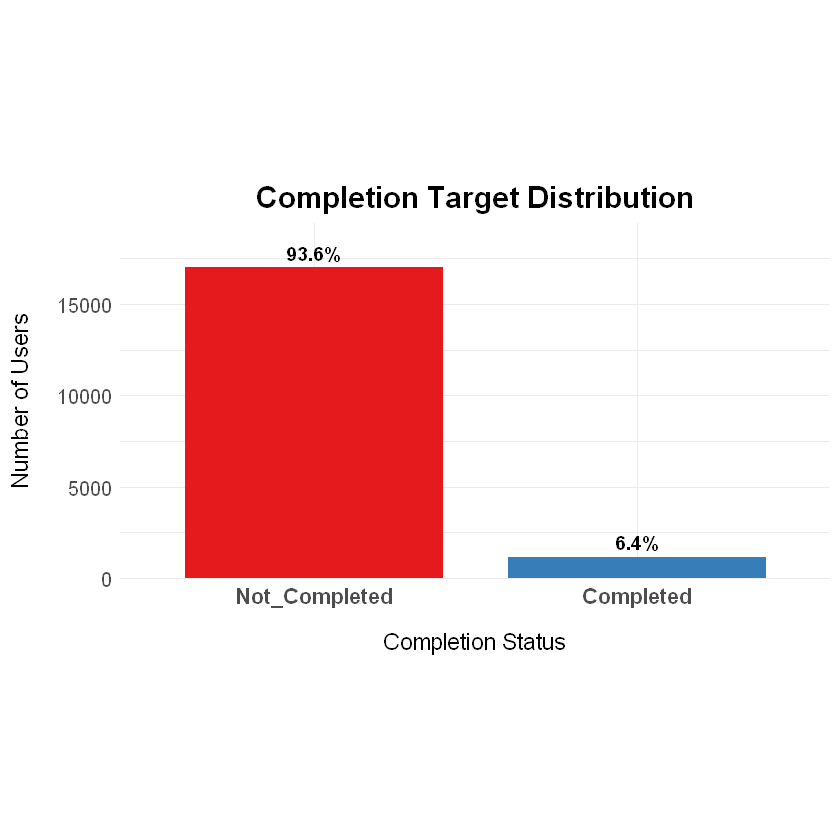

In [16]:
# Visualize the class distribution of the completion target.
ggplot(
  completion_summary,
  aes(
    x = completion_status,
    y = Count,
    fill = completion_status
  )
) +
  # Draw one bar for each completion class.
  geom_bar(
    stat = "identity",
    width = 0.8
  ) +

  # Display the percentage of users above each bar.
  geom_text(
    aes(label = paste0(round(Percentage, 1), "%")),
    vjust = -0.5,
    size = 4,
    fontface = "bold"
  ) +

  # Add vertical space above the highest bar
  # so that percentage labels remain visible.
  scale_y_continuous(
    limits = c(
      0,
      max(completion_summary$Count) * 1.12
    ),
    expand = expansion(mult = c(0, 0.02))
  ) +

  # Assign fixed colors to the two completion classes.
  scale_fill_manual(
    values = c(
      "Not_Completed" = "#E41A1C",
      "Completed" = "#377EB8"
    )
  ) +

  # Add chart title and axis labels.
  labs(
    title = "Completion Target Distribution",
    x = "Completion Status",
    y = "Number of Users"
  ) +

  # Apply a minimal visual theme.
  theme_minimal() +

  # Adjust chart proportions, text sizes, and label formatting.
  theme(
    aspect.ratio = 0.5,
    legend.position = "none",
    plot.title = element_text(
      size = 18,
      face = "bold",
      hjust = 0.5
    ),
    axis.title.x = element_text(
      size = 14,
      margin = ggplot2::margin(t = 15)
    ),
    axis.title.y = element_text(
      size = 14,
      margin = ggplot2::margin(r = 15)
    ),
    axis.text.x = element_text(
      size = 13,
      face = "bold"
    ),
    axis.text.y = element_text(size = 12)
  )

**Completion Target Analysis**

The completion target is highly imbalanced: **93.6%** `Not_Completed` versus **6.4%** `Completed`. This indicates that course completion is a rare outcome in the analytical sample and that the dataset is strongly skewed toward non-completers.

The final completion label is not included directly in the clustering feature space and is merged only after cluster construction. However, the feature set contains performance-related variables, particularly `score_per_active_day`, which is derived from the same accumulated score used to define completion. Therefore, the class imbalance does not directly influence K-means as a target distribution, but the observed completion differences across clusters are not fully independent of the clustering features.

---

## Behavioral Feature Engineering & Preprocessing

> **Technical Note: Analytical Sample**
>
>The clustering dataset is derived from `model_base`, which excludes both P99-defined extreme users and users still marked as `is_in_progress` at the dataset snapshot.

In [17]:
# Define base features for clustering 
features_clustering_base <- c(
    "active_days", 
    "median_gap_days", 
    "submission_correct_rate", 
    "view_frequency", 
    "submission_frequency", 
    "steps_per_active_day", 
    "score_per_active_day")

In [18]:
# Ensure all clustering features are numeric (required for distance-based algorithms)
sapply(cluster_features_model_base[, ..features_clustering_base], is.numeric)

active_days         median_gap_days submission_correct_rate 
                   TRUE                    TRUE                    TRUE 
         view_frequency    submission_frequency    steps_per_active_day 
                   TRUE                    TRUE                    TRUE 
   score_per_active_day 
                   TRUE

In [19]:
# Check variance for each feature: constant variables (var = 0) must be removed
apply(cluster_features_model_base[, ..features_clustering_base], 2, var)

active_days         median_gap_days submission_correct_rate 
             91.9718333            2251.4794379               0.1341882 
         view_frequency    submission_frequency    steps_per_active_day 
            117.6470499              17.1379399              56.2359908 
   score_per_active_day 
              7.2730505

>**Feature Variance Check**
>
>All selected features exhibit non-zero variance, confirming that no constant variables are present. 
>
>However, substantial differences in variance magnitude were observed across features 
(e.g., `median_gap_days` vs `submission_correct_rate`), indicating scale heterogeneity. 
>
>To prevent dominance of high-variance features in distance-based algorithms, 
all features are standardized prior to clustering.

---

### Log Transformation Diagnostics

>**Technical Note: Why Log Transformation Is Still Needed**
>
>Earlier diagnostics showed that P99-based filtering reduced extreme tails but did not eliminate the strong right-skewness of behavioral activity features. Therefore, log transformation is applied to reduce right skewness and extreme-value leverage. Z-score standardization is then used to place the features on comparable scales for Euclidean-distance calculations.

In [20]:
# Baseline (no log transformation)
# Standardize original features without log transformation
scaled_raw_features <- scale(cluster_features_model_base[, ..features_clustering_base])

# Convert to data.frame for diagnostics
z_scores_raw <- as.data.frame(scaled_raw_features)

In [21]:
# IMPORTANT:
# 'median_gap_days' is intentionally excluded from log transformation.
# It represents inactivity periods, and large values carry meaningful behavioral signal.
# Log transformation would compress these differences and reduce interpretability.
# Define heavily right-skewed features for log transformation
skewed_features <- c(
  "active_days",
  "view_frequency",
  "submission_frequency",
  "steps_per_active_day",
  "score_per_active_day"
)

In [22]:
# Preserve user_id separately for later cluster assignment
user_ids <- cluster_features_model_base$user_id

In [23]:
# Create a working copy of the dataset for preprocessing
clustering_scaled <- copy(cluster_features_model_base)

In [24]:
# Apply log1p transformation to reduce skewness and limit the influence of extreme values
# log1p(x) = log(1 + x) ensures stability when zeros are present
clustering_scaled[, (skewed_features) := lapply(.SD, log1p), .SDcols = skewed_features]

# Standardize features using Z-score normalization (required for K-means)
# This places the features on comparable variance scales
# before Euclidean-distance calculations.
clustering_scaled <- scale(clustering_scaled[, ..features_clustering_base])

# Convert to data.frame for diagnostics
z_scores_log <- as.data.frame(clustering_scaled)

In [25]:
# Count observations beyond ±3 standard deviations for each feature
# This helps assess the impact of log transformation on extreme values

cat("\nExtreme values count (Z-score > ±3) — WITHOUT log transformation:\n")
print(apply(z_scores_raw, 2, function(x) sum(abs(x) > 3)))

cat("\nExtreme values count (Z-score > ±3) — WITH log1p transformation:\n")
print(apply(z_scores_log, 2, function(x) sum(abs(x) > 3)))


Extreme values count (Z-score > ±3) — WITHOUT log transformation:
            active_days         median_gap_days submission_correct_rate 
                    331                     252                       0 
         view_frequency    submission_frequency    steps_per_active_day 
                    303                     298                     247 
   score_per_active_day 
                    280 

Extreme values count (Z-score > ±3) — WITH log1p transformation:
            active_days         median_gap_days submission_correct_rate 
                    129                     252                       0 
         view_frequency    submission_frequency    steps_per_active_day 
                    113                     356                      29 
   score_per_active_day 
                    146 


**Impact of Log Transformation**

Log transformation was applied to reduce right skewness and limit the influence of very large values in activity-based features.

* **Observed Effects:**

  * For most transformed features, including `active_days`, `view_frequency`, `steps_per_active_day`, and `score_per_active_day`, the number of observations with **|Z| > 3** decreased after transformation.
  * For `submission_frequency`, the number of observations with **|Z| > 3** increased. This occurs because `log1p()` compresses the variance of the zero-inflated distribution, causing more positive observations to exceed the recalculated three-standard-deviation threshold. This does not indicate a data quality issue.

* **Design Choice:**
  `median_gap_days` was intentionally not transformed because it represents inactivity intervals. Preserving its original scale maintains meaningful differences between users with shorter and longer inactivity periods.

* **Outlier Handling:**
  Highly atypical users were excluded earlier during the construction of `model_base`. Within the remaining analytical sample, residual upper-tail variation was retained and handled through log transformation and subsequent standardization rather than additional observation removal.

**Conclusion**

Log transformation reduced right skewness and the leverage of very large values in most activity-based features. Z-score standardization was then applied to place all clustering features on comparable scales for Euclidean-distance calculations.


---

### Correlation Matrix

In [26]:
# Calculate Pearson correlation for the final feature space
corr_matrix_final <- cor(clustering_scaled, use = "pairwise.complete.obs")

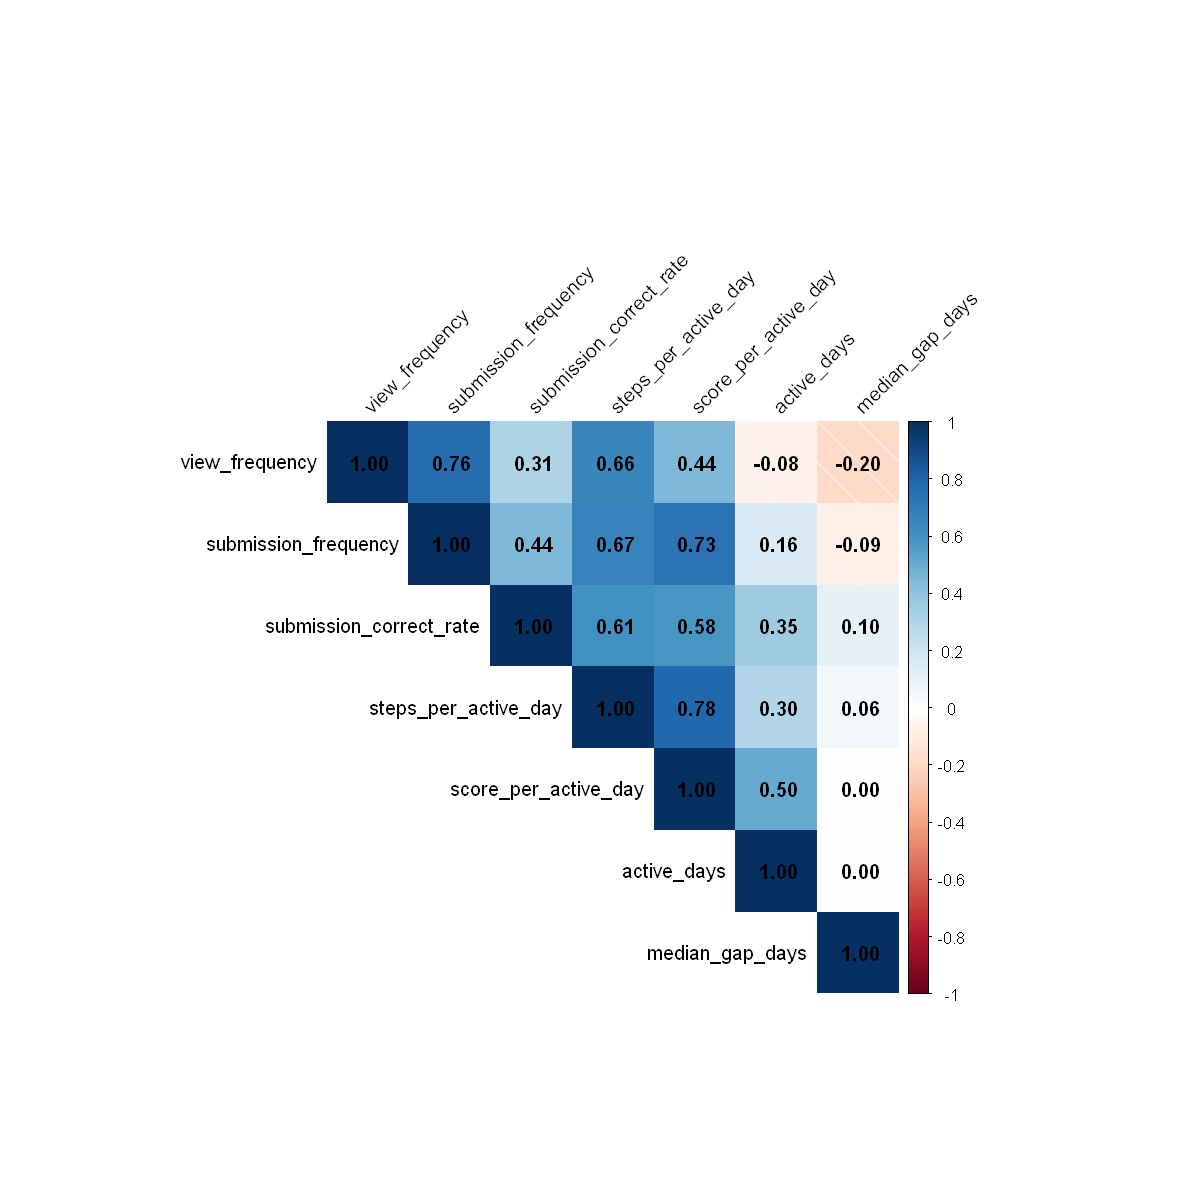

In [27]:
# Visualize correlations to inspect dependency structure across features
options(repr.plot.width = 10, repr.plot.height = 10)

corrplot(corr_matrix_final,
        method = "shade",
        type = "upper",
        order = "hclust",
        addCoef.col = "black",
        tl.col = "black",
        tl.srt = 45)

**Correlation Review**

The matrix shows expected positive relationships between engagement and productivity features. The strongest correlations are `steps_per_active_day` with `score_per_active_day` (**0.78**), `view_frequency` with `submission_frequency` (**0.76**), and `submission_frequency` with `score_per_active_day` (**0.73**).

`submission_correct_rate` is also moderately related to progress metrics, especially `steps_per_active_day` (**0.61**) and `score_per_active_day` (**0.58**). By contrast, `median_gap_days` has weak correlations with most features, suggesting that inactivity gaps capture a separate behavioral dimension.

Overall, the features are related but not redundant, so they are retained for clustering.

---

**Behavioral Feature Engineering & Preprocessing Summary**

- **Feature scope:** The clustering feature set combines engagement intensity, participation rhythm, practical activity, and performance-related signals.
- **Preprocessing strategy:** Right-skewed activity features were log-transformed, `median_gap_days` was preserved in its original scale, and all selected features were standardized using Z-score normalization.
- **Result:** The final feature space (`clustering_scaled`) preserves multiple dimensions of learner behavior while improving stability and suitability for distance-based clustering.

---

## K-Means Clustering: Model Selection

### Elbow Method

In [28]:
# Set seed for reproducibility: K-means starts with random centroids, 
# so we fix the seed to get consistent results every time we run the code.
set.seed(42)

# Fit K-means solutions for K = 1 to 10
# and store each fitted model.
wss_models <- lapply(1:10, function(k) {
  kmeans(
    clustering_scaled,
    centers = k,
    nstart = 50,
    iter.max = 100,
    algorithm = "Lloyd"
  )
})

# Extract the total within-cluster sum of squares
# from each fitted model for the elbow analysis.
wss <- vapply(
  wss_models,
  function(model) model$tot.withinss,
  numeric(1)
)

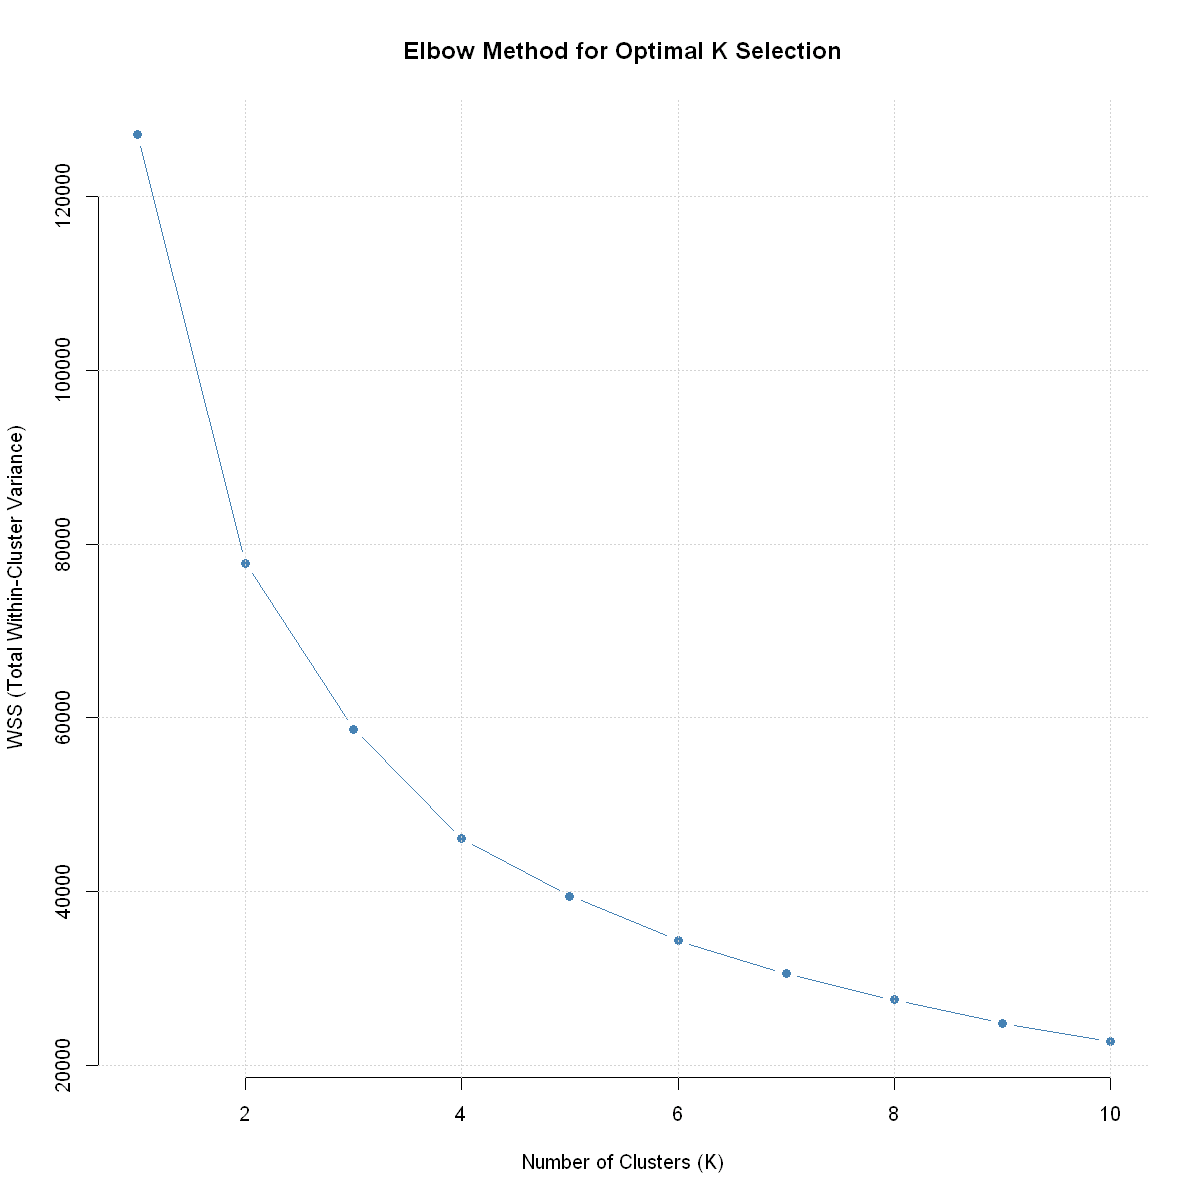

In [29]:
# Plotting the results to visually identify the 'elbow' point
plot(1:10, wss, type = "b", pch = 19, frame = FALSE, 
     xlab = "Number of Clusters (K)", 
     ylab = "WSS (Total Within-Cluster Variance)", 
     main = "Elbow Method for Optimal K Selection", 
     col = "steelblue")

grid()

**Optimal Cluster Selection: Elbow Method**

The Elbow Method was applied using WSS for $K = 1$ to $K = 10$ on the preprocessed feature space, where right-skewed activity variables were log-transformed and all selected features were standardized.

The curve shows a strong reduction in WSS up to approximately $K = 3$, with an additional visible improvement around $K = 4$. After $K = 4–5$, the marginal reduction in WSS becomes more gradual.

Therefore, the Elbow Method does not identify a single definitive optimal number of clusters. Instead, it suggests a plausible candidate range of $K = 3$ to $K = 5$.

The candidate solutions are compared using Silhouette Score, cluster size distribution, and business usability. After $K = 3$ is selected, bootstrap stability and PAM are used as robustness checks for the retained solution.

---

### Silhouette Analysis

In [30]:
# Compute a common distance matrix for silhouette-based comparison
dmat <- dist(clustering_scaled)

In [31]:
# Compute the average Silhouette Score for a given number of clusters (K)
# using the preprocessed feature matrix and its corresponding distance matrix.
silhouette_score <- function(k, data_matrix, data_dist) {
  set.seed(42)
  model <- kmeans(data_matrix, centers = k, nstart = 50, iter.max = 100)
  ss <- cluster::silhouette(model$cluster, data_dist)
  mean(ss[, 3])
}

# Evaluate average Silhouette Scores for K = 2 to K = 10
sil_scores <- sapply(2:10, function(k) silhouette_score(k, clustering_scaled, dmat))
setNames(round(sil_scores, 3), 2:10)                     

2     3     4     5     6     7     8     9    10 
0.447 0.467 0.473 0.473 0.439 0.432 0.436 0.439 0.441

**Cluster Validation: Silhouette Analysis**

The Silhouette Score was calculated for $K=2$ to $K=10$ to evaluate cluster cohesion and separation.

The Silhouette Scores for both $K = 4$ and $K = 5$ round to **0.473**, compared with **0.467** for $K = 3$. The differences between these solutions are minimal, indicating that the Silhouette criterion alone does not provide a clear preference for a single number of clusters.

Therefore, $K=3$, $K=4$, and $K=5$ were retained as candidate solutions for further evaluation. The final choice was based not only on the Silhouette Score but also on cluster size distribution, interpretability, and practical usefulness.

---

### Candidate Solution Comparison: $K = 3$, $K = 4$, and $K = 5$

In [32]:
# Fit candidate K-means solutions for comparison
set.seed(42)

kmeans_3 <- kmeans(
  x = clustering_scaled,
  centers = 3,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

kmeans_4 <- kmeans(
  x = clustering_scaled,
  centers = 4,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

kmeans_5 <- kmeans(
  x = clustering_scaled,
  centers = 5,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

In [33]:
# Silhouette comparison
sil_3 <- mean(cluster::silhouette(kmeans_3$cluster, dmat)[, 3])
sil_4 <- mean(cluster::silhouette(kmeans_4$cluster, dmat)[, 3])
sil_5 <- mean(cluster::silhouette(kmeans_5$cluster, dmat)[, 3])

In [34]:
# Cluster size comparison
k3_sizes <- data.table(
  K = 3,
  cluster = seq_along(kmeans_3$size),
  N = kmeans_3$size
)

k4_sizes <- data.table(
  K = 4,
  cluster = seq_along(kmeans_4$size),
  N = kmeans_4$size
)

k5_sizes <- data.table(
  K = 5,
  cluster = seq_along(kmeans_5$size),
  N = kmeans_5$size
)

cluster_size_k_compare <- rbind(k3_sizes, k4_sizes, k5_sizes)
cluster_size_k_compare[, Share := round(N / sum(N) * 100, 1), by = K]

In [35]:
# Summary table
k_comparison_summary <- data.table(
  K = c(3, 4, 5),
  silhouette_score = round(c(sil_3, sil_4, sil_5), 3),
  smallest_cluster_n = c(min(kmeans_3$size), min(kmeans_4$size), min(kmeans_5$size)),
  smallest_cluster_share = round(c(
    min(kmeans_3$size) / sum(kmeans_3$size) * 100,
    min(kmeans_4$size) / sum(kmeans_4$size) * 100,
    min(kmeans_5$size) / sum(kmeans_5$size) * 100
  ), 1)
)

k_comparison_summary
cluster_size_k_compare

K,silhouette_score,smallest_cluster_n,smallest_cluster_share
<dbl>,<dbl>,<int>,<dbl>
3,0.467,4148,22.8
4,0.473,185,1.0
5,0.473,186,1.0


K,cluster,N,Share
<dbl>,<int>,<int>,<dbl>
3,1,4148,22.8
3,2,4953,27.3
3,3,9067,49.9
4,1,9047,49.8
4,2,3946,21.7
4,3,185,1.0
4,4,4990,27.5
5,1,2686,14.8
5,2,4469,24.6


**Candidate Solution Comparison: $K = 3$, $K = 4$, and $K = 5$**

The candidate solutions $K = 3$, $K = 4$, and $K = 5$ were compared using two criteria: average Silhouette Score and cluster size distribution.

The Silhouette Score improves only marginally from **0.467** for $K = 3$ to **0.473** for both $K = 4$ and $K = 5$. This small increase suggests that introducing additional clusters provides only a limited improvement in cluster separation.

However, both $K = 4$ and $K = 5$ produce a very small cluster containing only about **1.0%** of the analytical sample (**185 and 186** learners, respectively).

In contrast, the $K = 3$ solution produces three well-balanced clusters, with the smallest segment representing **22.8%** of the analytical sample (**4,148** learners). This results in a more balanced segmentation while maintaining a Silhouette Score comparable to the higher-K solutions.

Therefore, $K = 3$ was selected as the final clustering solution, offering the best trade-off between clustering quality, balanced cluster sizes, and practical business usability.

---

## K-Means Clustering: Validation

In [36]:
# Use the final K = 3 K-means model for validation and downstream segmentation
final_kmeans_model <- kmeans_3

### Cluster Size Distribution

In [37]:
# Cluster sizes for the final K = 3 solution.
# These are algorithm-internal cluster labels before the size-based relabeling used for reporting.
final_cluster_sizes <- data.table(
  algorithm_cluster = seq_along(final_kmeans_model$size),
  N = final_kmeans_model$size
)

final_cluster_sizes[, Share := round(N / sum(N) * 100, 1)]

final_cluster_sizes

algorithm_cluster,N,Share
<int>,<int>,<dbl>
1,4148,22.8
2,4953,27.3
3,9067,49.9


**Cluster Size Distribution Check**

The final $K = 3$ solution produces three substantial algorithm-level clusters: **27.3%**, **49.9%**, and **22.8%** of the analytical sample. The smallest cluster still contains **4,148 users**, which is large enough for meaningful profiling and business interpretation.

These labels are algorithm-internal and are later reordered by segment size for reporting. This does not change the clustering solution; it only makes the final segment numbering easier to read.

Overall, the cluster size distribution supports the use of **K = 3** as a balanced and business-actionable segmentation. Unlike the **K = 4** and **K = 5** candidate solutions, it does not create a very small standalone segment of around **1.0%**.

---

### Cluster Stability Assessment

In [38]:
# Assess bootstrap stability of the final K = 3 solution
set.seed(42)

cb <- fpc::clusterboot(
  clustering_scaled,
  B = 100,
  clustermethod = fpc::kmeansCBI,
  krange = 3,
  seed = 42,
  count = FALSE,
  multipleboot = FALSE
)

# Average Jaccard stability score per cluster
setNames(round(cb$bootmean, 3), paste0("Cluster_", 1:3))

Cluster_1 Cluster_2 Cluster_3 
    0.977     0.918     0.919

In [39]:
# Compare the final K-means labels with the reference partition
# produced by clusterboot on the original dataset.
mapping_table <- table(
  kmeans_cluster = final_kmeans_model$cluster,
  cb_cluster = cb$partition
)

mapping_table

              cb_cluster
kmeans_cluster    1    2    3
             1    0 4148    0
             2    0    0 4953
             3 9067    0    0

**Cluster Stability Assessment**

The bootstrap results support the final **K = 3** solution. All three clusters show high average Jaccard stability scores (**0.977**, **0.918**, **0.919**), indicating that the segmentation is reproducible under resampling.

The mapping table confirms that the final K-means solution matches the reference partition produced by clusterboot, up to a permutation of cluster labels. Differences in cluster numbering are expected because cluster labels are algorithm-internal.

Overall, the final **K = 3** solution is stable enough for downstream profiling and interpretation.

---

### Clustering Method Comparison (K-means vs PAM)

>**Technical Note: K-means vs PAM**
>
> To assess whether the identified behavioral structure depends strongly on the choice of clustering algorithm, the K-means solution was compared with PAM (Partitioning Around Medoids), a more robust medoid-based alternative.

In [40]:
# Fit PAM with the same number of clusters as the final K-means solution
set.seed(42)

pam_model <- cluster::pam(clustering_scaled, k = 3)
pam_clusters <- pam_model$clustering

In [41]:
# Average silhouette scores
pam_sil <- cluster::silhouette(pam_clusters, dmat)
mean_pam_sil <- mean(pam_sil[, 3])

kmeans_sil <- cluster::silhouette(final_kmeans_model$cluster, dmat)
mean_kmeans_sil <- mean(kmeans_sil[, 3])

In [42]:
# Compare cluster size distributions across methods
kmeans_sizes <- as.data.table(table(final_kmeans_model$cluster))
setnames(kmeans_sizes, c("cluster", "N"))
kmeans_sizes[, method := "K-means"]

pam_sizes <- as.data.table(table(pam_clusters))
setnames(pam_sizes, c("cluster", "N"))
pam_sizes[, method := "PAM"]

size_comparison <- rbind(kmeans_sizes, pam_sizes)

In [43]:
# Measure agreement between K-means and PAM partitions
ari_kmeans_pam <- mclust::adjustedRandIndex(
  final_kmeans_model$cluster,
  pam_clusters
)

In [44]:
# Print key comparison metrics with readable labels
cat("Mean silhouette score (PAM):      ", round(mean_pam_sil, 3), "\n")
cat("Mean silhouette score (K-means):  ", round(mean_kmeans_sil, 3), "\n")
cat("Adjusted Rand Index (K-means vs PAM): ", round(ari_kmeans_pam, 3), "\n")

cat("\nCluster size comparison:\n")
print(size_comparison)

Mean silhouette score (PAM):       0.466 
Mean silhouette score (K-means):   0.467 
Adjusted Rand Index (K-means vs PAM):  0.948 

Cluster size comparison:
   cluster     N  method
    <char> <int>  <char>
1:       1  4148 K-means
2:       2  4953 K-means
3:       3  9067 K-means
4:       1  8981     PAM
5:       2  4779     PAM
6:       3  4408     PAM


**Method Comparison Results**

The final $K = 3$ K-means solution was compared with PAM as a robustness check.

The mean Silhouette Scores are almost identical: **0.467** for K-means and **0.466** for PAM. This indicates that both methods achieve a very similar level of internal cluster separation.

The Adjusted Rand Index is very high (**0.948**), showing strong agreement between the K-means and PAM partitions. This suggests that the main behavioral segmentation structure is not strongly dependent on the clustering algorithm.

The cluster size comparison also shows broadly similar segment structures across both methods. K-means produces three substantial segments of approximately **9,067**, **4,953**, and **4,148** users, while PAM produces comparable segment sizes of approximately **8,981**, **4,779**, and **4,408** users. The exact cluster numbering differs because cluster labels are algorithm-internal and do not have inherent meaning.

Overall, the comparison supports the robustness of the final $K = 3$ solution. K-means is retained as the primary method, while PAM confirms that the three-segment behavioral structure is broadly reproducible.


---

### Final Cluster Decision

Based on the candidate comparison and validation results, $K = 3$ is retained as the final primary segmentation.

The $K = 3$ solution has only a slightly lower Silhouette Score than $K = 4$ and $K = 5$, but it avoids very small standalone clusters and produces three substantial user groups. Bootstrap stability results show high cluster reproducibility, and the PAM comparison confirms that the three-segment structure is broadly robust across clustering methods.

Therefore, $K = 3$ provides the best balance between statistical quality, stability, interpretability, and business usability.

---

## K-Means Clustering: Assignment, Profiling, and Interpretation

### Cluster Assignment

In [45]:
# Create a user-level table containing the original K-means assignments
cluster_labels <- data.table(
  user_id = user_ids,
  cluster = final_kmeans_model$cluster
)

In [46]:
# Merge cluster labels with RAW (non-transformed) features
segmentation_data <- merge(
  cluster_features_model_base,
  cluster_labels,
  by = "user_id"
)

In [47]:
# Verify that merging cluster labels did not change the user-level granularity
stopifnot(nrow(segmentation_data) == nrow(cluster_features_model_base))
stopifnot(segmentation_data[, uniqueN(user_id)] == nrow(cluster_features_model_base))

In [48]:
# Create size-based cluster mapping (largest cluster = 1)
cluster_size_map <- segmentation_data[, .(Count = .N), by = cluster][order(-Count)]
cluster_size_map[, new_cluster := 1:.N]

In [49]:
# Recode clusters in the interpretation dataset
segmentation_data[cluster_size_map, on = "cluster", cluster := i.new_cluster]

In [50]:
# Convert to factor after recoding
segmentation_data[, cluster := as.factor(cluster)]

> **Technical Note on Cluster Labels**
>
> K-means cluster numbers are algorithm-internal labels and have no inherent order. For reporting, clusters were reordered by segment size, so **Cluster 1** represents the largest segment. This relabeling improves readability and does not change the clustering solution.

---

### Behavioral Profiling

In [51]:
# Recalculate cluster sizes AFTER recoding
cluster_sizes <- segmentation_data[, .(Count = .N), by = cluster]

In [52]:
# Cluster profiles are summarized using median values rather than means, 
# since the behavioral metrics are strongly right-skewed and contain extreme values. 
# This provides a more robust representation of typical user behavior within each segment.
cluster_profile <- segmentation_data[
  , lapply(.SD, median),
  by = cluster,
  .SDcols = features_clustering_base
]

In [53]:
# Merge sizes and profiles
display_table <- merge(cluster_sizes, cluster_profile, by = "cluster")

In [54]:
# Rename columns for reporting
setnames(display_table,
  c("cluster","Count","active_days","median_gap_days",
    "submission_correct_rate","view_frequency",
    "submission_frequency","steps_per_active_day","score_per_active_day"),
  c("Cluster_ID","Count","Active_Days","Median_Gap",
    "Submission_Correct_Rate","View_Frequency","Submission_Frequency",
    "Steps_Per_Active_Day","Score_Per_Active_Day")
)


In [55]:
# Add cluster share as a percentage of the full analytical sample
display_table[, Share := round(Count / sum(Count) * 100, 1)]

In [56]:
# Reorder columns so that Share appears directly after Count
setcolorder(display_table, c(
  "Cluster_ID", "Count", "Share",
  "Active_Days", "Median_Gap", "Submission_Correct_Rate",
  "View_Frequency", "Submission_Frequency",
  "Steps_Per_Active_Day", "Score_Per_Active_Day"
))

# Sort clusters by cluster ID for cleaner reporting
setorder(display_table, Cluster_ID)

# Display the final profiling table
display_table

Cluster_ID,Count,Share,Active_Days,Median_Gap,Submission_Correct_Rate,View_Frequency,Submission_Frequency,Steps_Per_Active_Day,Score_Per_Active_Day
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,9067,49.9,1,0,0.0000000,1.00000,0.0000000,1.00000,0.0
2,4953,27.3,9,2,0.5793651,1.12500,0.2579909,5.25000,1.2
3,4148,22.8,2,1,0.6428571,11.60556,3.0000000,10.16228,2.0


**Cluster Profile Table**

The table below summarizes the median behavioral profile of each cluster, together with cluster size and sample share. Median values are used to provide a robust representation of typical behavior within each segment, since the underlying behavioral variables are strongly right-skewed.

The profiles show clear heterogeneity across the three clusters in terms of participation continuity, activity intensity, practical engagement, and per-day productivity. These differences provide the empirical basis for the subsequent naming and interpretation of the behavioral segments.

---

### Segment Naming & Interpretation

In [57]:
# Mapping behavioral labels to cluster IDs
cluster_name_map <- data.table(
  cluster = as.factor(c(1, 2, 3)),
  cluster_name = c(
    "Passive Users",
    "Steady Learners",
    "Burst Learners"
  )
)

# Merge labels
segmentation_data <- merge(
  segmentation_data,
  cluster_name_map[, .(cluster, cluster_name)],
  by = "cluster"
)

# Optional integrity check: every user should now have a segment name
stopifnot(segmentation_data[, sum(is.na(cluster_name))] == 0)

**Behavioral Segmentation Analysis (K = 3)**

| Cluster | Segment Name | Size (%) | Profile | Key Insight |
|---|---|---:|---|---|
| **1** | Passive Users | **49.9%** | Minimal engagement, no meaningful practical activity, and no observable score progress in the median profile | Represents the dominant early-disengagement segment, where most users drop out before meaningful activation |
| **2** | Steady Learners | **27.3%** | The highest median number of active days, moderate practical participation, and stable learning progress | Represents the most sustained and behaviorally consistent learner segment |
| **3** | Burst Learners | **22.8%** | The highest median interaction frequency, practical intensity, and per-day productivity | Captures concentrated high-intensity learning behavior |

**Interpretive Summary**

The 3-cluster solution highlights substantial heterogeneity in learner behavior while keeping the segmentation balanced and business-actionable. The largest segment consists of users with minimal engagement and almost no practical progression, suggesting that disengagement is concentrated at the earliest stage of the learning journey.

The remaining two segments represent more engaged learning patterns: one with more sustained participation over time, and one with concentrated high-intensity activity. Overall, the main differences across segments are associated with continuity of participation, activity intensity, practical engagement, and per-day productivity.

Compared with the higher-K alternatives, this solution avoids creating very small standalone segments and is therefore more suitable for scalable business interpretation and retention strategy design.

---

## Completion Status Across User Segments

In [58]:
# Preserve row count before merge
n_before_merge <- nrow(segmentation_data)

# Merge target into segmentation dataset
segmentation_data <- merge(
  segmentation_data,
  completion_target_model_base,
  by = "user_id",
  all.x = TRUE
)

In [59]:
# Integrity checks after merge
stopifnot(nrow(segmentation_data) == n_before_merge)
stopifnot(segmentation_data[, uniqueN(user_id)] == n_before_merge)
stopifnot(segmentation_data[, sum(is.na(completion_status))] == 0)

In [60]:
# Fix segment order according to cluster ID
segmentation_data[, cluster := factor(cluster, levels = c(1, 2, 3))]
segmentation_data[, cluster_name := factor(
  cluster_name,
  levels = c(
    "Passive Users",
    "Steady Learners",
    "Burst Learners"
  )
)]

In [61]:
# Calculate target distribution within each cluster
cluster_completion <- segmentation_data[
  , .N, by = .(cluster, cluster_name, completion_status)
][
  , pct := N / sum(N), by = .(cluster, cluster_name)
]

In [62]:
# Reshape completion shares into a wide table:
# one row per segment, separate columns for Completed and Not_Completed
cluster_completion_wide <- dcast(
  cluster_completion,
  cluster + cluster_name ~ completion_status,
  value.var = "pct",
  fill = 0
)

In [63]:
# Convert proportions to percentages
cluster_completion_wide[, `:=`(
  Completed = round(Completed * 100, 1),
  Not_Completed = round(Not_Completed * 100, 1)
)]

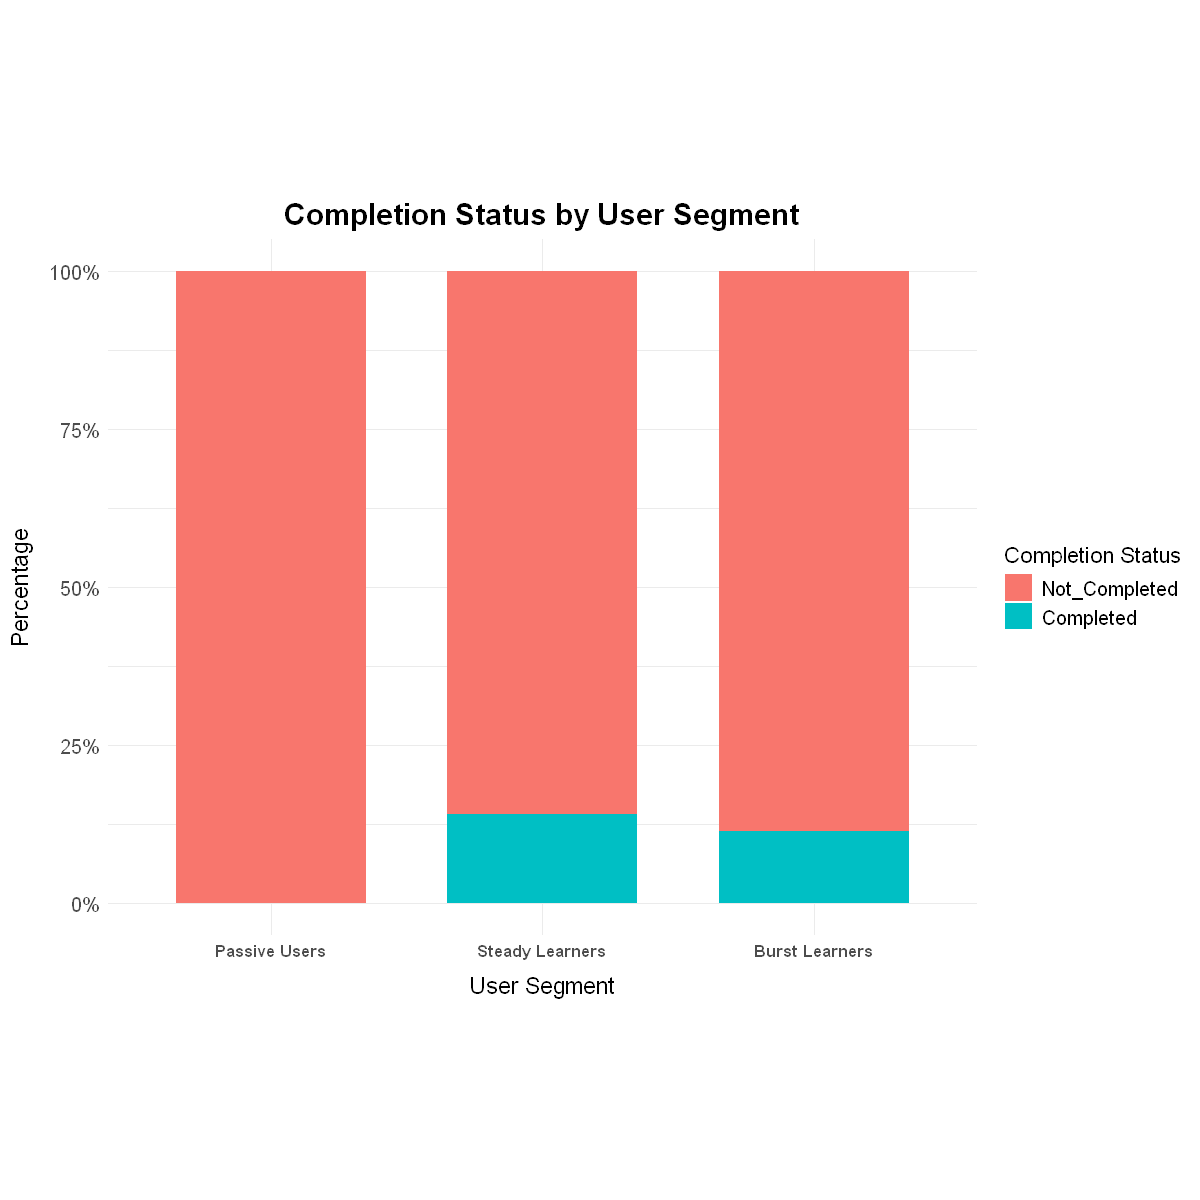

In [64]:
# Plot
ggplot(cluster_completion, aes(x = cluster_name, y = pct, fill = completion_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_y_continuous(labels = scales::percent) +
 labs(
  title = "Completion Status by User Segment",
  x = "User Segment",
  y = "Percentage",
  fill = "Completion Status"
  )+
  theme_minimal() +
  theme(
    aspect.ratio = 0.8,
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, margin = margin(t = 10)),
    axis.title.y = element_text(size = 14, margin = margin(r = 10)),
    axis.text.x = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 12),
    legend.title = element_text(size = 13),
    legend.text = element_text(size = 12)
  )

**Completion Status Across User Segments**

> **Executive Summary**
>
> The distribution of completion status differs across the three behavioral segments, but **Not_Completed** remains the dominant outcome in every group.
>
> Completion is almost absent among **Passive Users**, while both **Steady Learners** and **Burst Learners** show a visible minority of completed users. These differences are consistent with the segment profiles, which combine engagement, practical activity, continuity, and performance-related variables. Because the clustering includes `score_per_active_day`, the completion breakdown is descriptive and should not be interpreted as independent evidence of completion probability.

**Interpretation**

- **Passive Users**  
  This segment is almost entirely composed of **Not_Completed** users. The near-zero completion share is consistent with the segment profile: minimal engagement, no meaningful practical activity, and no observable score progress in the median profile.

- **Steady Learners**  
  This segment shows the highest completion share among the three groups. Although `Not_Completed` remains the majority outcome, this segment combines sustained participation with a higher observed completion share. Because performance-related variables contribute to the clustering, this relationship is interpreted descriptively.
- **Burst Learners**  
  This segment also contains a visible share of completed users. Its completion pattern is consistent with a profile characterized by concentrated high-intensity activity, stronger practical engagement, and higher per-day productivity. The observed completion share forms part of the descriptive segment profile rather than an independent validation result.

**Overall Conclusion**

The segment-level completion breakdown provides an additional descriptive characterization of the 3-cluster solution. **Steady Learners** and **Burst Learners** show higher completion shares than **Passive Users**.

However, the completion comparison is not an independent validation of the cluster structure because the feature space includes performance-related variables, particularly `score_per_active_day`, which is derived from the accumulated score used to define completion.

---

## Assumptions & Limitations

**Assumptions**

- The processed datasets correctly represent the resolved analytical sample (`model_base`) and are consistently linked by `user_id`.
- The selected clustering features capture meaningful dimensions of learner engagement, continuity, practical activity, and performance.
- Log transformation and Z-score normalization improve comparability across behavioral features for distance-based clustering.
- The K-means solution provides a useful approximation of mixed behavioral-performance learner profiles, even though real user behavior may vary along a continuum rather than in perfectly separated groups.
- The final 3-cluster solution is treated as the primary business segmentation because it provides substantial and interpretable user groups.

**Limitations**

- The analysis is restricted to `model_base`, which excludes both P99-defined extreme users and users still marked as `is_in_progress` at the dataset snapshot; therefore, results should not be interpreted as a full-population view of all learners.
- Completion remains a rare outcome in the analytical sample, so segment-level completion comparisons should be interpreted descriptively rather than as strong inferential evidence.
- K-means assumes relatively compact cluster structure and is sensitive to feature selection, scaling, and preprocessing choices.
- The 3-cluster solution prioritizes business interpretability and segment size over finer-grained separation. Rare small-segment patterns observed in the $K = 4$ and $K = 5$ candidate solutions are not treated as standalone operational segments.
- The analysis is based on a historical snapshot and does not capture unobserved external factors that may influence learner outcomes.
- Some clustering features include performance-related signals, particularly `score_per_active_day`, which is derived from the accumulated score also used to define completion. The segmentation should therefore be interpreted as a mixed behavioral-performance profile, and completion-share differences should not be treated as independent validation of the cluster structure.

---

## Final Conclusion

Combined with the product findings from [**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb), this analysis shows that the resolved learner population contains distinct engagement and performance profiles. These profiles differ in continuity, practical activation, activity intensity, productivity, and observed completion share.

The final behavioral segmentation identifies three core learner groups: **Passive Users**, who show minimal engagement and almost no practical progress; **Steady Learners**, who demonstrate the most sustained participation pattern; and **Burst Learners**, who show the highest interaction intensity and strongest per-day productivity.

The segment-level distribution of completion outcomes shows that **Not_Completed** remains the dominant outcome across all segments. At the same time, completion is relatively more frequent among the more engaged segments, especially **Steady Learners** and **Burst Learners**, while **Passive Users** show almost no successful completion.

These results indicate that clustering captures meaningful differences in full-history engagement and performance profiles. The segments also show different observed completion shares, but these differences should be interpreted descriptively because performance-related variables contribute directly to the cluster construction.

The analysis highlights continuity of participation, practical engagement intensity, and score productivity as important dimensions for describing learner heterogeneity.

Overall, the final outcome of the analysis is twofold:

- a mixed behavioral-performance 3-segment user structure that summarizes distinct resolved learning trajectories, and
- a descriptive cluster-level comparison of completion outcomes across these profiles.

This provides a stronger analytical foundation for both **retention strategy design** and **downstream completion modeling**, while keeping the segmentation practical and business-actionable.

**Connection to the Next Project Stage**

This segmentation analysis provides the exploratory behavioral context for the supervised modeling phase.

The final $K = 3$ solution shows that learner behavior can be summarized into three broad profiles: **Passive Users**, **Steady Learners**, and **Burst Learners**. These profiles show that engagement continuity, practical activation, activity intensity, and performance-related productivity vary across segments with different observed completion shares. Because the clusters include score-related information, this comparison provides descriptive context rather than independent predictive confirmation.

[**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) builds on this insight by moving from segment-level interpretation to user-level prediction. Instead of using cluster labels as inputs, the supervised model uses early 10-day behavioral and progress-aware features to estimate `P(Completed)` and derive the inverted business risk score:

`Risk_Not_Completed = 1 - P(Completed)`

Thus, **Part 2** explains behavioral heterogeneity, while [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) translates early-window behavioral and progress-related signals into a practical retention prioritization workflow.

---